# Исходные данные

Отдел маркетинга хочет понимать насколько у нас стабилен спрос на продукцию и что нам необходимо сделать для его повышения.

In [203]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

Исходные данные. Это все __возможные__ продажи по нашей клиентской базе. 

Но __не все__ наши клиенты покупают у нас каждый день.

In [111]:

def get_source_data():
    # Генерация исходных данных
    # Параметры
    num_rows = 1000000
    start_date = "2023-01-01"
    end_date = "2024-12-31"

    # Генерация дат
    date_range = pd.date_range(start=start_date, end=end_date, freq='D')
    dates = np.random.choice(date_range, size=num_rows, replace=True)

    # сортировка по дате
    dates.sort()

    # Генерация случайных значений
    random_values = np.round(np.random.exponential(scale=3.0, size=num_rows), 2)
    random_values = np.array([i*1e-7 + n for i, n in enumerate(random_values)])

    # Создание DataFrame
    df = pd.DataFrame({
        'Date': dates,
        'Value': random_values
    })

    return df

df = get_source_data()

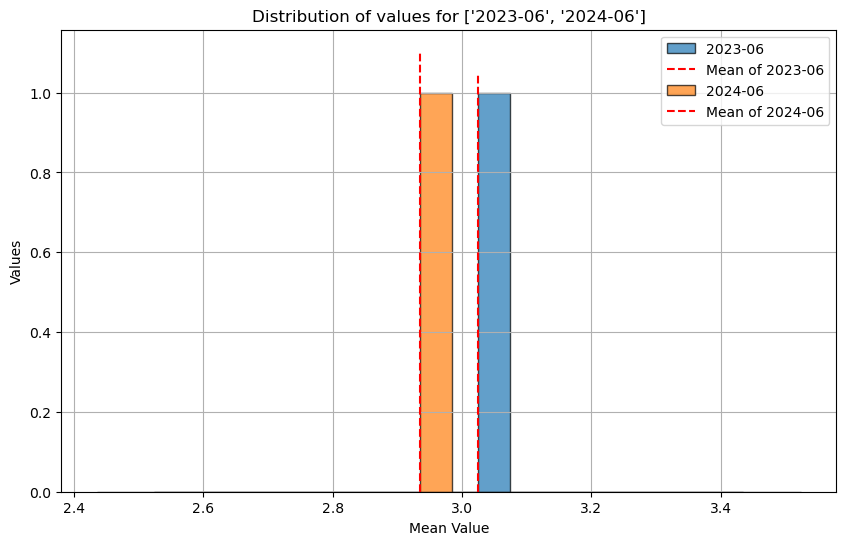

In [249]:
# Получим данные за определенный месяц

selected_months = ['2023-06', '2024-06']
plt.figure(figsize=(10, 6))
month_means = []

for selected_month in selected_months:
        
    monthly_data = df[df['Date'].dt.to_period('M') == selected_month]

    sample_means = []
    for _ in range(1):
        sample = monthly_data.sample(n=300)
        sample_means.append(sample['Value'].mean())

    # Вычисление мат. ожидания и дисперсии
    expected_value = np.mean(sample_means)
    variance_value = np.var(sample_means)
    # Построение распределения выборочных средних

    plt.hist(sample_means, bins=20, alpha=0.7, edgecolor='black', label=selected_month)
    plt.vlines(expected_value, 0, plt.ylim()[1], color='red', linestyles='dashed', label=f'Mean of {selected_month}')
    month_means.append(sample_means)

plt.xlabel('Mean Value')
plt.ylabel('Values')
plt.legend()
plt.title(f'Distribution of values for {selected_months}')
plt.grid()
plt.show()


In [236]:
month_means = np.array(month_means)

In [237]:
# Проведение t-теста
statistic, p_value = stats.ttest_ind(month_means[1], month_means[0])
print(f"t-статистика: {statistic:.2f}, p-значение: {p_value:.8f}")

if p_value < 0.05:
    print("Отклоняем H0: статистически значимые различия обнаружены.")
else:
    print("Не отклоняем H0: статистически значимые различия не обнаружены.")

t-статистика: 5.97, p-значение: 0.00000001
Отклоняем H0: статистически значимые различия обнаружены.


In [216]:
# # Средние значения по суткам и по месяцам
# daily_avg = df.groupby(df['Date'].dt.date)['Value'].mean()
# monthly_avg = df.groupby(df['Date'].dt.to_period('M'))['Value'].mean()

In [218]:
# # Визуализация средних значений
# plt.figure(figsize=(12, 6))
# plt.plot(daily_avg.index, daily_avg.values, label='Daily Average')
# plt.xlabel('Date')
# plt.ylabel('Average Value')
# plt.title('Daily Average Values')
# plt.legend()
# plt.grid()
# plt.show()